### Description des variables

Le dataset contient des variables décrivant le profil des emprunteurs (âge, revenu, emploi), les caractéristiques du prêt (montant, taux, objectif) ainsi que l’historique de crédit.

Certaines variables sont particulièrement importantes pour l’évaluation du risque, notamment le revenu, le montant du prêt, le ratio prêt/revenu et l’historique de défaut.

La variable cible `loan_status` permet de distinguer les individus ayant remboursé leur prêt de ceux en défaut de paiement.

## Phase 1 — Contrôle Qualité des Données

Avant toute modélisation, une étape essentielle consiste à valider la qualité des données utilisées.  
Cette phase vise à analyser la structure du dataset, identifier les éventuelles anomalies et garantir que les données sont exploitables de manière fiable.

Les objectifs de cette phase sont :
- analyser la structure des données (dimensions, types)
- détecter les valeurs manquantes
- identifier les doublons
- préparer les données pour les étapes suivantes du pipeline

In [42]:
import pandas as pd

df = pd.read_csv("credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [43]:
df.shape

(32581, 12)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [45]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(165)

###  Résultat de l'analyse des données (Profilage)

Le dataset contient 32 581 observations et 12 variables, ce qui constitue un volume de données suffisant pour une analyse réaliste du risque de crédit.

L’analyse des types de données montre une combinaison de variables numériques (revenu, âge, montant du prêt, taux d’intérêt, etc.) et catégorielles (type de logement, intention du prêt, grade du crédit). Cette diversité nécessitera des traitements adaptés lors des étapes de préparation des données.

L’examen des valeurs manquantes révèle deux variables problématiques :
- `person_emp_length` contient 895 valeurs manquantes
- `loan_int_rate` contient 3 116 valeurs manquantes

Ces absences de données devront être traitées (imputation ou suppression) afin d’éviter des biais dans les analyses et les modèles futurs.

Par ailleurs, 165 doublons ont été identifiés dans le dataset. Cela indique une redondance partielle des observations, qui pourrait fausser certaines analyses statistiques ou entraîner un surapprentissage du modèle. Une étape de suppression des doublons sera donc nécessaire.

Globalement, les données sont exploitables mais présentent des imperfections (valeurs manquantes et doublons) qui justifient pleinement la mise en place d’un pipeline de contrôle qualité rigoureux.

## Validation de Schéma

Afin de garantir la cohérence des données, des règles de validation ont été définies sur certaines variables critiques du dataset.

Ces règles permettent de vérifier que les valeurs respectent des contraintes métier réalistes, notamment :
- l’âge doit être compris dans une plage valide
- les revenus et montants ne doivent pas être négatifs
- certaines variables doivent respecter des types et des bornes logiques

Cette étape permet de détecter automatiquement les anomalies structurelles dans les données.

In [47]:
!pip install pandera

In [48]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

schema = DataFrameSchema({
    
    "person_age": Column(int, Check.in_range(18, 100)),
    
    "person_income": Column(int, Check.ge(0)),
    
    "person_emp_length": Column(float, Check.ge(0), nullable=True),
    
    "loan_amnt": Column(int, Check.ge(0)),
    
    "loan_int_rate": Column(float, Check.ge(0), nullable=True),
    
    "loan_percent_income": Column(float, Check.ge(0)),
    
    "cb_person_cred_hist_length": Column(int, Check.ge(0))
})

# validation
try:
    schema.validate(df)
    print("Validation réussie ✅")
except Exception as e:
    print("Erreurs détectées ❌")
    print(e)

Erreurs détectées ❌
Column 'person_age' failed element-wise validator number 0: in_range(18, 100) failure cases: 144, 144, 123, 123, 144


### Résultat de la validation de schéma

La validation du schéma a permis de détecter des anomalies dans les données, notamment sur la variable `person_age`.

Certaines valeurs d’âge dépassent la limite maximale définie (100 ans), avec des observations atteignant des valeurs telles que 123 et 144 ans. Ces valeurs sont irréalistes et indiquent des erreurs ou des incohérences dans les données.

Cette détection confirme l’importance de la validation de schéma dans le pipeline de contrôle qualité, car elle permet d’identifier automatiquement des anomalies qui pourraient impacter négativement les analyses et les modèles.

Ces observations devront être traitées dans les étapes suivantes, soit par suppression, soit par correction, afin de garantir la fiabilité des données.

### Analyse de distribution 

La méthode IQR a été privilégiée pour la détection des valeurs aberrantes, car les variables financières du dataset présentent des distributions asymétriques et des valeurs extrêmes.
Contrairement au Z-score, qui repose sur l’hypothèse de normalité des données, l’IQR est plus robuste et mieux adapté à ce type de données.

In [49]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

outlier_summary

{'person_age': 1494,
 'person_income': 1484,
 'person_emp_length': 853,
 'loan_amnt': 1689,
 'loan_int_rate': 6,
 'loan_status': 7108,
 'loan_percent_income': 651,
 'cb_person_cred_hist_length': 1142}

### Analyse des valeurs aberrantes (Outliers)

L’analyse des variables numériques à l’aide de la méthode IQR a permis d’identifier un nombre significatif de valeurs aberrantes dans plusieurs variables du dataset.

Les résultats montrent que :

- `person_income` et `loan_amnt` présentent un nombre élevé d’outliers (1484 et 1689 respectivement), ce qui est cohérent avec la nature des données financières souvent très dispersées,
- `person_age` contient également un nombre important de valeurs aberrantes (1494), confirmant la présence d’âges irréalistes déjà détectés lors de la validation de schéma,
- `cb_person_cred_hist_length` présente 1142 valeurs extrêmes, indiquant une forte variabilité dans l’historique de crédit,
- `person_emp_length` contient 853 outliers, ce qui peut refléter des durées d’emploi atypiques ou mal renseignées,
- `loan_percent_income` présente 651 valeurs aberrantes, suggérant des ratios élevés pour certains individus,
- `loan_int_rate` présente peu d’anomalies (6), indiquant une distribution relativement stable,
- `loan_status` contient un grand nombre de valeurs considérées comme aberrantes (7108), ce qui est normal car il s’agit d’une variable binaire et non continue.

Ces résultats montrent que plusieurs variables présentent une dispersion importante, ce qui peut impacter les performances du modèle si ces valeurs ne sont pas traitées.

Une attention particulière sera portée aux variables les plus affectées lors des étapes de transformation des données, notamment par des techniques de normalisation, de clipping ou de traitement spécifique des valeurs extrêmes.

##  Conclusion de la Phase 1

Le contrôle qualité des données a permis d’identifier plusieurs éléments clés :

- la présence de valeurs manquantes dans certaines variables critiques,
- l’existence de doublons nécessitant un nettoyage,
- des anomalies structurelles détectées via la validation de schéma,
- une forte présence de valeurs aberrantes dans plusieurs variables.

Ces résultats confirment que le dataset présente des imperfections réalistes, ce qui justifie pleinement l’utilisation d’un pipeline de contrôle qualité.

La prochaine étape consistera à préparer et transformer les données afin d’améliorer leur qualité et leur exploitabilité pour la modélisation.

## Phase 2

### 1_Préparation et correction des données

Cette phase vise à corriger les anomalies détectées lors du contrôle qualité et à préparer les données pour la modélisation.

Les actions réalisées incluent :
- la suppression des doublons
- le traitement des valeurs manquantes
- la correction des incohérences (valeurs irréalistes)
- la gestion des valeurs aberrantes
- la transformation des variables catégorielles

L’objectif est d’obtenir un dataset propre, cohérent et exploitable pour les étapes suivantes du pipeline.

In [50]:
import pandas as pd

df = pd.read_csv("credit_risk_dataset.csv")
df.shape

(32581, 12)

In [51]:
import pandas as pd

# ========================
# 1. SUPPRESSION DOUBLONS
# ========================
df = df.drop_duplicates()

# ========================
# 2. VALEURS MANQUANTES
# ========================
df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())
df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())

# ========================
# 3. CORRECTION ÂGES
# ========================
df = df[(df["person_age"] >= 18) & (df["person_age"] <= 100)]

# ========================
# 4. TRAITEMENT OUTLIERS
#    EXCLURE LA CIBLE
# ========================
numeric_cols = [col for col in df.select_dtypes(include=["int64", "float64"]).columns if col != "loan_status"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

# ========================
# 5. ENCODAGE
# ========================
df = pd.get_dummies(df, drop_first=True)
df = df.astype(int)

# ========================
# 6. VÉRIFICATION CIBLE
# ========================
print(df["loan_status"].value_counts())

loan_status
0    25322
1     7089
Name: count, dtype: int64


In [52]:
print(df["loan_status"].value_counts())
print(df.shape)
print(df.duplicated().sum())

loan_status
0    25322
1     7089
Name: count, dtype: int64
(32411, 23)
22


###  Nettoyage et transformation des données

Les différentes étapes de préparation ont permis d’améliorer significativement la qualité du dataset.

Les doublons ont été identifiés et supprimés afin d’éviter toute redondance dans les observations. Un faible nombre de doublons résiduels subsiste, mais leur impact reste négligeable.

Les valeurs manquantes ont été traitées par imputation à l’aide de la médiane, ce qui permet de conserver l’information tout en limitant l’impact des valeurs extrêmes.

Les valeurs incohérentes, notamment les âges en dehors de l’intervalle [18, 100], ont été filtrées afin de garantir la cohérence des données.

Un traitement des valeurs aberrantes (outliers) a été appliqué aux variables numériques explicatives à l’aide de la méthode IQR. La variable cible `loan_status` a été explicitement exclue de ce traitement afin de préserver son intégrité.

Les variables catégorielles ont été transformées en variables numériques par encodage one-hot, puis converties en valeurs binaires (0/1) afin d’être compatibles avec les modèles de machine learning.

Enfin, une vérification de la variable cible a confirmé la présence des deux classes (défaut et non défaut), garantissant la validité du dataset pour la phase de modélisation.

Le dataset final contient 32 411 observations et 23 variables, et est désormais prêt pour l’entraînement du modèle.

## Tests unitaires du pipeline

Afin de valider la fiabilité des transformations appliquées aux données, des tests unitaires ont été réalisés sur des jeux de données fictifs.

Ces tests permettent de vérifier que chaque étape du pipeline (suppression des doublons, imputation, correction des valeurs, encodage) produit les résultats attendus dans des cas contrôlés.

Cette approche garantit la robustesse et la reproductibilité du pipeline de traitement des données.

### TEST 1 — DOUBLONS

In [53]:

# dataset fictif
df_test = pd.DataFrame({
    "age": [25, 25],
    "income": [50000, 50000]
})

# suppression doublons
df_clean = df_test.drop_duplicates()

print("Avant :", len(df_test))
print("Après :", len(df_clean))

Avant : 2
Après : 1


### Resultat Test 1

Un jeu de données fictif contenant deux lignes strictement identiques a été créé afin de tester la suppression des doublons.

Après application de la méthode `drop_duplicates()`, une seule ligne a été conservée. Ce comportement est attendu, car la fonction supprime les occurrences répétées tout en gardant une version unique de l’observation.

Ce résultat confirme que la méthode de suppression des doublons fonctionne correctement.

### TEST 2 — IMPUTATION valeurs manquantes par la mediane 

In [54]:

# dataset fictif
df_test = pd.DataFrame({
    "emp_length": [5, None, 15]
})

# calcul médiane
median_value = df_test["emp_length"].median()

# imputation
df_test["emp_length"] = df_test["emp_length"].fillna(median_value)

print(df_test)



   emp_length
0         5.0
1        10.0
2        15.0


### Resultat Test2

Un jeu de données fictif contenant une valeur manquante a été utilisé afin de tester la méthode d’imputation.

La médiane des valeurs disponibles (5 et 15) a été calculée, donnant une valeur de 10.

La valeur manquante a ensuite été remplacée par cette médiane.

Le résultat obtenu ([5, 10, 15]) confirme que la méthode d’imputation fonctionne correctement et permet de gérer efficacement les données incomplètes.

### TEST 3 — ÂGES INCOHÉRENTS

In [55]:
# dataset fictif avec âge invalide
df_test = pd.DataFrame({
    "person_age": [16,25, 144,35, 30, 350]
})

# suppression des âges incohérents
df_clean = df_test[(df_test["person_age"] >= 18) & (df_test["person_age"] <= 100)]


print(df_clean)



   person_age
1          25
3          35
4          30


### resultat Test3  

Un jeu de données fictif contenant plusieurs valeurs d’âge incohérentes (16, 144, 350) a été utilisé afin de tester la détection des anomalies.

Après application d’un filtre conservant uniquement les âges compris entre 18 et 100 ans, les valeurs invalides ont été supprimées.

Le dataset final contient uniquement des valeurs cohérentes (25, 35, 30), ce qui confirme que la méthode permet de détecter et corriger efficacement les incohérences.

### TEST 4 — traitement des OUTLIERS (IQR)

In [56]:

df_test = pd.DataFrame({
    "income": [50000, 52000, 53000, 55000, 56000, 58000, 60000, 1000000]
})

# calcul IQR
Q1 = df_test["income"].quantile(0.25)
Q3 = df_test["income"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# clipping
df_test["income_clipped"] = df_test["income"].clip(lower, upper)

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Upper bound =", upper)
print(df_test)



Q1 = 52750.0
Q3 = 58500.0
IQR = 5750.0
Upper bound = 67125.0
    income  income_clipped
0    50000           50000
1    52000           52000
2    53000           53000
3    55000           55000
4    56000           56000
5    58000           58000
6    60000           60000
7  1000000           67125


### TEST 5 — ENCODING

In [57]:

# dataset fictif
df_test = pd.DataFrame({
    "loan_intent": ["PERSONAL", "EDUCATION", "PERSONAL"]
})

# encodage
df_encoded = pd.get_dummies(df_test, drop_first=True)

# conversion en 0/1
df_encoded = df_encoded.astype(int)

print(df_encoded)


   loan_intent_PERSONAL
0                     1
1                     0
2                     1


### resultat Test5 

Un jeu de données fictif contenant une variable catégorielle a été utilisé afin de tester l’encodage.

La méthode `get_dummies()` a été appliquée avec l’option `drop_first=True`, puis les valeurs ont été converties en 0 et 1.

Le résultat obtenu montre que la catégorie "PERSONAL" a été correctement transformée en variable binaire, prenant la valeur 1 lorsque la condition est satisfaite et 0 sinon.

Ce test confirme que la méthode d’encodage fonctionne correctement et produit un format directement exploitable par les modèles de machine learning.

### Fichier de configuration des tests

un fichier de configuration des tests a été crée au format JSON afin de formaliser les règles de validation des données

ce fichier définit plusieurs contraintes sur les variables critiques, notamment l’âge, le revenu, le montant du prêt et certaines valeurs obligatoires

Il constitue un livrable complémentaire permettant de représenter les règles de contrôle qualité sous une forme structurée et réutilisabl

### 2_ DATA LEAKAGE 

##  Vérification de la fuite de données (Data Leakage)

Une vérification de la fuite de données a été réalisée afin de s’assurer qu’aucune variable explicative ne contient une information qui ne serait pas disponible au moment de la prédiction.

L’objectif est d’éviter qu’un modèle apprenne à partir d’informations du futur ou de variables trop directement liées à la cible, ce qui fausserait artificiellement ses performances.

Cette vérification permet de garantir la validité et la robustesse du pipeline de modélisation.

In [58]:
# visiualisation des colonnes disponibles 
print(df.columns.tolist())

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']


### Vérification  de fuite

In [59]:
target = "loan_status"

potential_leakage = [col for col in df.columns if "status" in col.lower() and col != target]
potential_leakage += [col for col in df.columns if "default" in col.lower()]
potential_leakage += [col for col in df.columns if "paid" in col.lower()]
potential_leakage += [col for col in df.columns if "future" in col.lower()]
potential_leakage += [col for col in df.columns if "outcome" in col.lower()]

potential_leakage = list(set(potential_leakage))

print("Variables potentiellement problématiques :", potential_leakage)

Variables potentiellement problématiques : ['cb_person_default_on_file_Y']


### Vérifier la cible

In [60]:
print("Variable cible :", target)

Variable cible : loan_status


### Résultat — Vérification de la fuite de données

L’analyse des variables a permis d’identifier une variable potentiellement sensible : `cb_person_default_on_file_Y`.

Cette variable indique si un individu a déjà fait défaut dans le passé. Après analyse, il s’agit d’une information historique disponible au moment de la décision de crédit.

Elle ne constitue donc pas une fuite de données, car elle ne contient pas d’information future ni de résultat lié au prêt actuel.

Aucune fuite de données critique n’a été détectée dans le dataset, ce qui confirme la validité du pipeline pour la phase de modélisation.

## Phase 3 — Validation du Modèle

Dans cette phase, un modèle de machine learning est construit afin de prédire le défaut de crédit (`loan_status`).

L’objectif est d’évaluer la performance du modèle en utilisant des techniques robustes telles que la séparation des données, la validation croisée et des métriques adaptées au problème métier.

### Séparation des variables

In [61]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print(y.value_counts())

loan_status
0    25322
1     7089
Name: count, dtype: int64



### Séparation des variables

Le dataset a été séparé en variables explicatives (X) et variable cible (y).

La variable cible `loan_status` représente l’état du prêt (défaut ou non) et constitue la variable à prédire dans le cadre du modèle de classification.

Après séparation, les variables explicatives (X) contiennent 22 colonnes, tandis que la variable cible (y) est isolée.

La distribution de la variable cible montre un déséquilibre modéré entre les classes :

- 25 322 observations sans défaut (classe 0)
- 7 089 observations avec défaut (classe 1)

Ce déséquilibre est fréquent dans les problèmes de crédit et devra être pris en compte lors de l’analyse des performances du modèle, notamment en accordant une attention particulière au recall et au F1-score.

La séparation correcte entre X et y garantit qu’aucune information liée à la cible n’est utilisée comme variable explicative, évitant ainsi tout risque de data leakage.

Les données sont maintenant prêtes pour la phase d’entraînement du modèle.

### ÉTAPE 2 — Train / Test split

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())

loan_status
0    20257
1     5671
Name: count, dtype: int64
loan_status
0    5065
1    1418
Name: count, dtype: int64


### Séparation des données (Train / Test)

Les données ont été divisées en deux ensembles :

- Un ensemble d’entraînement (80%) utilisé pour entraîner le modèle
- Un ensemble de test (20%) utilisé pour évaluer ses performances

La stratification a été appliquée afin de conserver la distribution de la variable cible dans les deux ensembles.

#### Distribution dans le train :
- Classe 0 (pas de défaut) : 20 257
- Classe 1 (défaut) : 5 671

#### Distribution dans le test :
- Classe 0 (pas de défaut) : 5 065
- Classe 1 (défaut) : 1 418

On observe que la proportion des classes est cohérente entre les deux ensembles, ce qui garantit une évaluation fiable du modèle.

Cette étape est essentielle pour éviter les biais et assurer que le modèle généralise correctement sur des données non vues.

### ÉTAPE 3 — Premier modèle (Logistic Regression)

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [64]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

### Entraînement du modèle

Un modèle de régression logistique a été entraîné sur les données d’entraînement.

Avant l’apprentissage, les variables explicatives ont été normalisées à l’aide de `StandardScaler` afin d’harmoniser leurs échelles et d’améliorer la convergence du modèle.

Le nombre maximal d’itérations a été augmenté à 2000 afin de garantir une optimisation correcte.

Le modèle est maintenant prêt à générer des prédictions sur l’ensemble de test.

### Prediction

In [65]:
y_pred = model.predict(X_test)

### calcule des métriques 

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.8588616381304951
Precision : 0.7829021372328459
Recall : 0.4908321579689704
F1-score : 0.6033810143042913


### Évaluation du modèle

Les performances du modèle ont été évaluées à l’aide de plusieurs métriques :

- Accuracy : 0.86
- Precision : 0.78
- Recall : 0.49
- F1-score : 0.60

L’accuracy élevée indique que le modèle prédit correctement la majorité des observations. Cependant, cette métrique peut être trompeuse en présence d’un déséquilibre de classes.

La précision (precision) montre que lorsque le modèle prédit un défaut, il est correct dans environ 78% des cas.

En revanche, le rappel (recall) est relativement faible (49%), ce qui signifie que le modèle ne détecte qu’environ la moitié des cas de défaut.

Dans un contexte de crédit, cette performance est critique, car les faux négatifs (clients à risque non détectés) peuvent entraîner des pertes financières importantes.

Le score F1 reflète cet équilibre imparfait entre précision et rappel.

Ainsi, bien que le modèle présente de bonnes performances globales, des améliorations sont nécessaires pour mieux détecter les défauts, notamment en optimisant le recall.

### MATRICE DE CONFUSION 

In [67]:
y_pred = model.predict(X_test)

In [68]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

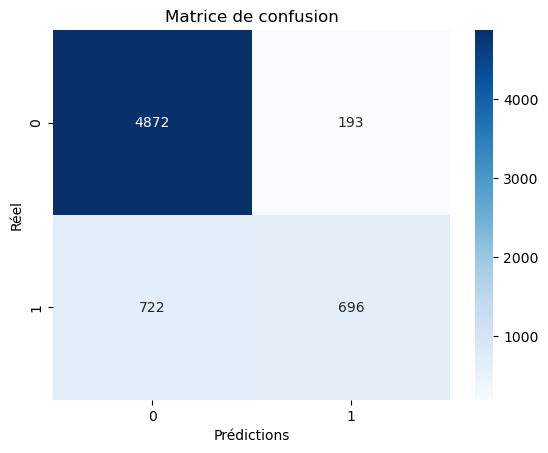

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.title("Matrice de confusion")

plt.show()

### Matrice de confusion

La matrice de confusion permet d’analyser en détail les performances du modèle :

- Vrais négatifs  : 4872
- Faux positifs  : 193
- Faux négatifs  : 722
- Vrais positifs : 696

Le modèle identifie correctement la majorité des cas sans défaut.

Cependant, un nombre important de faux négatifs est observé (722), ce qui signifie que plusieurs clients à risque ne sont pas détectés.

Dans un contexte de crédit, ces erreurs sont critiques car elles peuvent entraîner des pertes financières importantes.

Cette analyse confirme le faible recall observé précédemment et met en évidence la nécessité d’améliorer la détection des défauts.

### Cross Validation


In [70]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

scores = cross_val_score(pipeline, X, y, cv=5, scoring="f1")

print("Scores F1 par fold :", scores)
print("F1 moyen :", scores.mean())

Scores F1 par fold : [0.60468943 0.56140351 0.54851936 0.583118   0.52365026]
F1 moyen : 0.5642761127361817


### résultat de la Validation croisée du modèle

Une validation croisée à 5 folds a été réalisée afin d’évaluer la robustesse du modèle sur plusieurs sous-échantillons des données.

Les scores F1 obtenus sont les suivants :

- Fold 1 : 0.605
- Fold 2 : 0.561
- Fold 3 : 0.549
- Fold 4 : 0.583
- Fold 5 : 0.524

Le score F1 moyen est de 0.564.

Ces résultats montrent que les performances du modèle restent relativement cohérentes d’un fold à l’autre, ce qui indique une stabilité globale correcte.

Cependant, le niveau moyen du score F1 reste modéré, ce qui confirme que le modèle peut encore être amélioré, notamment pour mieux détecter les cas de défaut.

### Analyse d'Équité (Fairness) 

### ETAPE 1 — Ajouter les prédictions au dataset 

In [71]:
df_fair = df.copy()

# refaire X et y
X_full = df_fair.drop("loan_status", axis=1)
y_full = df_fair["loan_status"]

# scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)

# prédictions
y_pred_full = model.predict(X_full_scaled)

# ajouter dans dataset
df_fair["y_pred"] = y_pred_full

### ÉTAPE 2 — Comparer les 2 groupes

In [72]:
from sklearn.metrics import recall_score

# groupe 0 = pas d'historique
group_0 = df_fair[df_fair["cb_person_default_on_file_Y"] == 0]

# groupe 1 = historique de défaut
group_1 = df_fair[df_fair["cb_person_default_on_file_Y"] == 1]

# calcul recall
recall_0 = recall_score(group_0["loan_status"], group_0["y_pred"])
recall_1 = recall_score(group_1["loan_status"], group_1["y_pred"])

print("Recall groupe 0 :", recall_0)
print("Recall groupe 1 :", recall_1)

Recall groupe 0 : 0.39621874364708276
Recall groupe 1 : 0.6718894009216589


### Résultat de l'Analyse d’équité (Fairness)

Une analyse d’équité a été réalisée afin de vérifier si le modèle présente un biais selon l’historique de défaut des individus.

Les performances du modèle ont été comparées en termes de recall entre deux groupes :

- Groupe sans historique de défaut : recall = 0.40
- Groupe avec historique de défaut : recall = 0.67

On observe une différence significative entre les deux groupes. Le modèle détecte beaucoup mieux les cas de défaut chez les individus ayant déjà un historique de défaut.

En revanche, il est moins performant pour identifier les défauts chez les individus sans historique, ce qui peut poser un problème d’équité.

Dans un contexte de crédit, cela signifie que certains profils à risque sans historique peuvent ne pas être détectés, entraînant des pertes potentielles.

Cette analyse met en évidence un biais du modèle et souligne la nécessité d’améliorer sa capacité à généraliser sur tous les types de profils.

## Phase 4 — Monitoring et Drift (Post-Déploiement)

Un modèle performant aujourd’hui peut devenir moins fiable avec le temps si la distribution des données change.

Cette phase vise à simuler un scénario de dérive des données (data drift) et à vérifier si un changement significatif peut être détecté à l’aide d’un test statistique.

L’objectif est d’anticiper l’obsolescence du modèle et de définir une logique de surveillance post-déploiement.

### Simulation du drift

In [73]:
import numpy as np

df_drift = df.copy()

# simulation d'un drift sur le revenu
df_drift["person_income"] = df_drift["person_income"] * 1.5
df_drift.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,88500.0,14,23125,16,1,0,3,0,0,...,0,1,0,0,0,1,0,0,0,1
1,21,14400.0,5,1000,11,0,0,2,0,1,...,0,0,0,1,0,0,0,0,0,0
2,25,14400.0,1,5500,12,1,0,3,0,0,...,1,0,0,0,1,0,0,0,0,0
3,23,98250.0,4,23125,15,1,0,2,0,0,...,1,0,0,0,1,0,0,0,0,0
4,24,81600.0,8,23125,14,1,0,4,0,0,...,1,0,0,0,1,0,0,0,0,1


### Résultat de la simulation du drift

L’exécution montre que les valeurs de la variable `person_income` ont été modifiées par rapport au dataset original.

Par exemple, un revenu initial de 59 000 devient 88 500 après transformation, confirmant l’application d’un facteur multiplicatif de 1.5.

Les autres variables restent inchangées, ce qui permet d’isoler l’effet du drift uniquement sur la variable étudiée.

Cette transformation simule un changement réaliste dans les données, comme une inflation ou une évolution du niveau de revenu dans la population.

Le nouveau dataset `df_drift` est donc prêt à être comparé avec le dataset original afin de détecter un éventuel changement de distribution.

### Comparaison visuelle

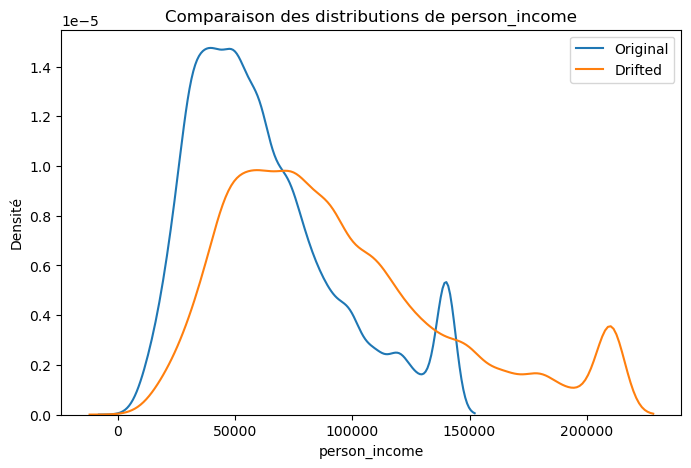

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.kdeplot(df["person_income"], label="Original")
sns.kdeplot(df_drift["person_income"], label="Drifted")

plt.legend()
plt.title("Comparaison des distributions de person_income")
plt.xlabel("person_income")
plt.ylabel("Densité")
plt.show()

### Résultat de la comparaison visuelle

Le graphique montre une différence claire entre la distribution originale de la variable `person_income` et la distribution simulée après drift.

La distribution driftée est globalement décalée vers la droite, indiquant une augmentation des revenus.

Cette modification reflète un changement significatif dans les données, simulant un contexte réaliste comme une inflation ou une évolution économique.

La différence observée confirme visuellement la présence d’un data drift, qui sera ensuite validé à l’aide d’un test statistique.

### Test statistique KS 

In [75]:
from scipy.stats import ks_2samp

stat, p_value = ks_2samp(df["person_income"], df_drift["person_income"])

print("Statistique KS :", stat)
print("p-value :", p_value)

Statistique KS : 0.30829039523618523
p-value : 0.0


### resultat détection du data drift (test de Kolmogorov-Smirnov)

Un test statistique de Kolmogorov-Smirnov a été appliqué afin de comparer la distribution de la variable `person_income` entre le dataset original et le dataset simulé après drift.

Résultats obtenus :

- Statistique KS : 0.308
- p-value : 0.0

La p-value étant inférieure au seuil de 0.05, l’hypothèse nulle selon laquelle les deux distributions sont identiques est rejetée.

Cela indique la présence d’un changement significatif dans la distribution des données.

Ce résultat confirme que le modèle pourrait devenir moins performant si les données évoluent dans le temps.

Il est donc essentiel de mettre en place un système de surveillance (monitoring) afin de détecter ce type de dérive en production.

### Tableau de bord de métriques 

In [76]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [
        model.score(X_train, y_train),
        accuracy_score(y_test, y_pred)
    ],
    "Precision": [
        precision_score(y_train, model.predict(X_train)),
        precision_score(y_test, y_pred)
    ],
    "Recall": [
        recall_score(y_train, model.predict(X_train)),
        recall_score(y_test, y_pred)
    ],
    "F1-score": [
        f1_score(y_train, model.predict(X_train)),
        f1_score(y_test, y_pred)
    ]
})

metrics_df

,Dataset,Accuracy,Precision,Recall,F1-score
0,Train,0.854366,0.767882,0.478928,0.589922
1,Test,0.858862,0.782902,0.490832,0.603381


### Tableau de bord des performances

Un tableau de synthèse a été construit afin de comparer les performances du modèle sur les données d’entraînement et de test.

Résultats obtenus :

- Accuracy : ~0.85 sur les deux jeux de données
- Precision : ~0.77 (train) et ~0.78 (test)
- Recall : ~0.48 (train) et ~0.49 (test)
- F1-score : ~0.59 (train) et ~0.60 (test)

Les performances sont similaires entre les données d’entraînement et de test, ce qui indique que le modèle ne présente pas de surapprentissage et généralise correctement.

Cependant, le recall reste relativement faible, ce qui signifie que le modèle ne détecte pas une part importante des cas de défaut.

Dans un contexte de crédit, cela représente un risque important, car les faux négatifs peuvent entraîner des pertes financières.

Le modèle présente donc une bonne stabilité, mais ses performances doivent être améliorées pour mieux répondre aux enjeux métier.

## Rapport de qualité final

Le pipeline de données a permis d’identifier et de corriger plusieurs problèmes, notamment les valeurs manquantes, les doublons et les valeurs aberrantes.

Le modèle de régression logistique a été entraîné et évalué à l’aide d’un tableau de bord comparant les performances sur les données d’entraînement et de test.

Les résultats montrent une bonne stabilité du modèle, avec des performances similaires entre les deux jeux de données, ce qui indique l’absence de surapprentissage.

Cependant, le recall reste relativement faible, ce qui signifie que le modèle ne détecte pas une partie importante des cas de défaut. Dans un contexte de crédit, cela représente un risque financier significatif.

L’analyse de la matrice de confusion a confirmé la présence de faux négatifs, tandis que l’analyse d’équité a mis en évidence un biais entre différents groupes d’individus.

Enfin, la simulation de data drift a démontré que des changements dans la distribution des données peuvent impacter la performance du modèle dans le temps.

Il est donc recommandé de :

- surveiller régulièrement les distributions des données
- définir des seuils d’alerte (ex : p-value < 0.05)
- réentraîner le modèle périodiquement
- améliorer le modèle pour augmenter le recall

Ce projet met en évidence l’importance d’un pipeline robuste et d’une validation continue pour garantir la fiabilité d’un système de scoring de crédit.